# Проект модуля. Сканирование кубического мира: детекция персонажей в Minecraft с FCOS и YOLO

Проверяем все ли установлено верно и работает)

In [1]:
# import torch 
# import mmcv 
# import mmdet 
# from mmcv.ops import RoIAlign, nms 

# print("=" * 50) 
# print(f"PyTorch Version: {torch.__version__}") 
# print(f"CUDA Available: {torch.cuda.is_available()}") 
# if torch.cuda.is_available(): 
#     print(f"GPU: {torch.cuda.get_device_name(0)}") 
# print(f"MMCV Version: {mmcv.__version__}") 
# print(f"MMDet Version: {mmdet.__version__}") 
# print("-" * 50) 

# try: 
#     # Тест CUDA операций 
#     print("✅ MMCV CUDA Ops loaded successfully") 
# except ImportError as e: 
#     print(f"❌ CUDA Ops Failed: {e}") 

# try: 
#     # Тест импорта реестра моделей 
#     from mmdet.registry import MODELS 
#     print("✅ MMDetection Registry working") 
# except Exception as e: 
#     print(f"❌ MMDetection Init Failed: {e}") 

# print("=" * 50)

In [2]:
import json
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import json
from pathlib import Path
import json
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt
import mmcv
from mmdet.apis import init_detector, inference_detector
import os
from ultralytics import YOLO
import os
import random
import numpy as np
from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmengine.runner import Runner
from mmdet.registry import MODELS, DATASETS
import torch
import os
import sys
from mmengine.config import Config
from mmengine.registry import init_default_scope
from mmengine.runner import Runner
import torch
from datetime import datetime
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

## Этап 2. Исследовательский анализ (EDA) и работа с данными

Pascal VOC (Visual Object Classes) — это название знаменитого конкурса по распознаванию образов, который во многом сформировал современные подходы к детекции. Для конкурса был создан особый формат разметки, основанный на XML. Он долгое время был стандартом и используется до сих пор.

Пример формата такой разметки:

СНАЧАЛА, ПЕРЕД ТЕМ КАК КОНВЕРТИРОВАТЬ ДАННЫЕ В JSON, ПРОВЕРИМ У ВСЕХ ЛИ ИЗОБРАЖЕНИЙ ЕСТЬ АННОТАЦИИ:

In [3]:
def find_missing_pairs_xml(folder_path):
    """
    Проверяет соответствие изображений и XML-аннотаций в папке VOC.
    
    Args:
        folder_path (str): путь к папке с изображениями и аннотациями
        
    Returns:
        tuple(list, list, int, int): 
            - список изображений без аннотаций
            - список аннотаций без изображений
            - общее число изображений
            - общее число аннотаций
    """
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))]
    xml_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.xml')]

    # убираем расширения для сравнения
    image_stems = {os.path.splitext(f)[0]: f for f in image_files}
    xml_stems = {os.path.splitext(f)[0]: f for f in xml_files}

    # изображения без аннотаций
    images_without_annotations = [image_stems[stem] for stem in image_stems.keys() - xml_stems.keys()]

    # аннотации без изображений
    annotations_without_images = [xml_stems[stem] for stem in xml_stems.keys() - image_stems.keys()]

    return images_without_annotations, annotations_without_images, len(image_files), len(xml_files)


def main_xml(folder_path):
    """
    Основная функция для проверки соответствия XML-аннотаций и изображений.
    """
    if not os.path.exists(folder_path):
        return f"Папка не найдена: {folder_path}"

    images_without_annotations, annotations_without_images, total_images, total_annotations = find_missing_pairs_xml(folder_path)

    report = []

    if images_without_annotations:
        report.append("Изображения без соответствующих меток:")
        for fn in images_without_annotations:
            report.append(f"  - {fn}")
        report.append(f"Всего: {len(images_without_annotations)} изображений")

    if annotations_without_images:
        report.append("\nАннотации без соответствующих изображений:")
        for fn in annotations_without_images:
            report.append(f"  - {fn}")
        report.append(f"Всего: {len(annotations_without_images)} аннотаций")

    report.append("\nИтоговая статистика:")
    report.append(f"  Всего изображений: {total_images}")
    report.append(f"  Всего меток: {total_annotations}")
    valid_pairs = total_images - len(images_without_annotations)
    report.append(f"  Полных пар: {valid_pairs}")

    return "\n".join(report)

In [4]:
folders = {
    "train": r"C:\Users\admin\mmdetection\datasets\minecraft\train",
    "valid": r"C:\Users\admin\mmdetection\datasets\minecraft\valid",
    "test":  r"C:\Users\admin\mmdetection\datasets\minecraft\test",
}

for split, folder in folders.items():
    print(f"\n# {split}")
    result = main_xml(folder)
    if result:
        print(result)


# train

Итоговая статистика:
  Всего изображений: 2304
  Всего меток: 2304
  Полных пар: 2304

# valid

Итоговая статистика:
  Всего изображений: 422
  Всего меток: 422
  Полных пар: 422

# test

Итоговая статистика:
  Всего изображений: 155
  Всего меток: 155
  Полных пар: 155


УДАЛЯЕМ ИЗОБРАЖЕНИЯ БЕЗ РАЗМЕТКИ !!! а после конвертируем в JSON

Для начала проверим, что структура JSON корректна --->

На мой взгляд достаточно будет убедится в 3-х вещах:
1) JSON-файл успешно читается
2) В нем есть ожидаемые ключи (info, licenses, categories, images, annotations)
3) Аннотации содержат обязательные поля (bbox, category_id, image_id)

In [5]:
annotations_path = Path("datasets/minecraft/annotations/_annotations.voc.json")

with open(annotations_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Тип корневого обьекта:", type(data))
print("Ключи верхнего уровня:", data.keys())

Тип корневого обьекта: <class 'dict'>
Ключи верхнего уровня: dict_keys(['images', 'annotations', 'categories'])


In [6]:
annotations_dir = Path("datasets/minecraft/annotations")

annotations_files = [
    "train_annotations.voc.json",
    "valid_annotations.voc.json",
    "test_annotations.voc.json", 
]

for fname in annotations_files:
    print(f"\nПроверка файла: {fname}")


    with open(annotations_dir / fname, "r", encoding="utf-8") as f:
        data = json.load(f)

    print(" Тип корневого обьекта:", type(data))
    print(" Ключи верхнего уровня:", data.keys())

    assert isinstance(data, dict)
    assert {"images", "annotations", "categories"}.issubset(data.keys())
    
    print("Структура JSON корректна")


Проверка файла: train_annotations.voc.json
 Тип корневого обьекта: <class 'dict'>
 Ключи верхнего уровня: dict_keys(['images', 'annotations', 'categories'])
Структура JSON корректна

Проверка файла: valid_annotations.voc.json
 Тип корневого обьекта: <class 'dict'>
 Ключи верхнего уровня: dict_keys(['images', 'annotations', 'categories'])
Структура JSON корректна

Проверка файла: test_annotations.voc.json
 Тип корневого обьекта: <class 'dict'>
 Ключи верхнего уровня: dict_keys(['images', 'annotations', 'categories'])
Структура JSON корректна


Теперь проверим, что количество изображений совпадает с количеством аннотаций --->

In [7]:
import os
import json

def find_missing_pairs(images, annotations):
    """
    Проверяет соответствие изображений и аннотаций в JSON.

    Args:
        images (list[dict]): список изображений из JSON
        annotations (list[dict]): список аннотаций из JSON

    Returns:
        tuple[list[str], list[str]]:
            - file_name изображений без аннотаций
            - image_id аннотаций без изображений (редко встречается)
    """
    image_id_to_name = {img["id"]: img["file_name"] for img in images}
    image_ids = set(image_id_to_name.keys())
    annotation_image_ids = {ann["image_id"] for ann in annotations}

    images_without_annotations = [image_id_to_name[i] for i in image_ids - annotation_image_ids]
    annotations_without_images = list(annotation_image_ids - image_ids)

    return images_without_annotations, annotations_without_images, len(images), len(annotations)
    

def main(json_path):
    """Основная функция проверки соответствия JSON-аннотаций"""

    if not os.path.exists(json_path):
        return f"Файл аннотаций не найден: {json_path}"

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    images = data.get("images", [])
    annotations = data.get("annotations", [])

    images_without_annotations, annotations_without_images, total_images, total_annotations = find_missing_pairs(images, annotations)

    report = []

    if images_without_annotations:
        report.append("Изображения без соответствующих меток:")
        for fn in images_without_annotations:
            report.append(f"  - {fn}")
        report.append(f"Всего: {len(images_without_annotations)} изображений")

    if annotations_without_images:
        report.append("\nАннотации без изображений:")
        for img_id in annotations_without_images:
            report.append(f"  - image_id: {img_id}")
        report.append(f"Всего: {len(annotations_without_images)} аннотаций")

    report.append("\nИтоговая статистика:")
    report.append(f"  Всего изображений: {total_images}")
    report.append(f"  Всего меток: {total_annotations}")
    valid_pairs = total_images - len(images_without_annotations)
    report.append(f"  Полных пар: {valid_pairs}")

    return "\n".join(report)

In [8]:
annotation_files = {
    "train": "datasets/minecraft/annotations/train_annotations.voc.json",
    "valid": "datasets/minecraft/annotations/valid_annotations.voc.json",
    "test":  "datasets/minecraft/annotations/test_annotations.voc.json",
}

for split, path in annotation_files.items():
    print(f"\n# {split}")
    result = main(path)
    if result:
        print(result)


# train

Итоговая статистика:
  Всего изображений: 2304
  Всего меток: 4022
  Полных пар: 2304

# valid

Итоговая статистика:
  Всего изображений: 422
  Всего меток: 697
  Полных пар: 422

# test

Итоговая статистика:
  Всего изображений: 155
  Всего меток: 351
  Полных пар: 155


Отлично, у каждого изображения есть своя аннотация а иногда и по нескольку) 

Далее, проанализируем распределение классов, визуализируем его и сделаем вывод о наличии дисбаланса)

In [9]:
def analyze_class_distribution_json(json_path: str):
    """
    Анализирует распределение классов в JSON датасете COCO/VOC и строит гистограмму.
    
    Args:
        json_path (str): путь к файлу аннотаций train_annotations.voc.json
    """
    if not os.path.exists(json_path):
        print(f"Файл не найден: {json_path}")
        return

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    categories = data.get('categories', [])
    annotations = data.get('annotations', [])

    if not categories or not annotations:
        print("Нет категорий или аннотаций в JSON")
        return

    # создаём словарь id -> name
    id_to_name = {cat['id']: cat['name'] for cat in categories}

    class_counter = Counter()
    for ann in annotations:
        class_id = ann['category_id']
        class_counter[class_id] += 1

    if not class_counter:
        print("Нет объектов для анализа")
        return

    sorted_class_ids = sorted(class_counter.keys())
    labels = [id_to_name[i] for i in sorted_class_ids]
    counts = [class_counter[i] for i in sorted_class_ids]

    plt.figure(figsize=(12, 8))
    bars = plt.bar(labels, counts, color='skyblue')
    
    plt.title('Распределение классов в обучающем датасете', fontsize=16)
    plt.xlabel('Классы', fontsize=12)
    plt.ylabel('Количество экземпляров', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # подписи значений сверху каждой полоски
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count),
                 ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('class_distribution_json.png')
    plt.show()


In [10]:
train_json_path = r"datasets/minecraft/annotations/train_annotations.voc.json"
test_json_path = r"datasets/minecraft/annotations/test_annotations.voc.json"
valid_json_path = r"datasets/minecraft/annotations/valid_annotations.voc.json"

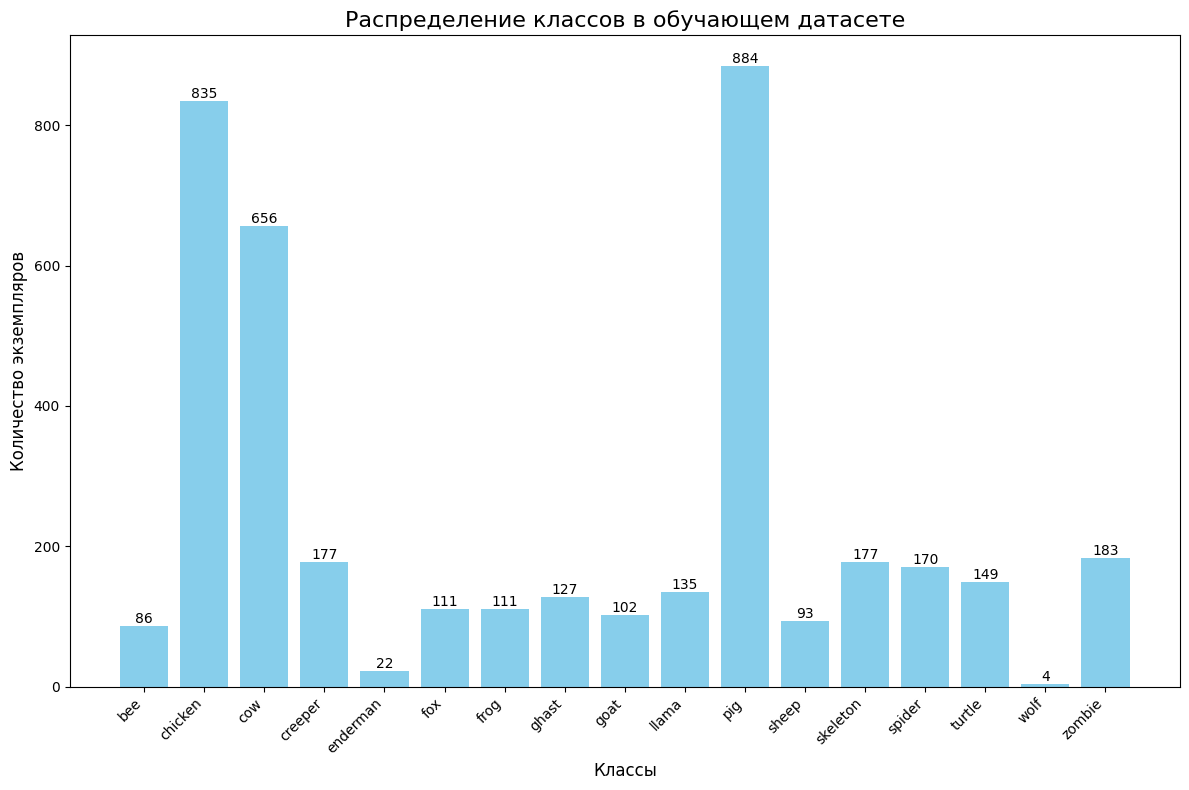

In [11]:
analyze_class_distribution_json(train_json_path)

Видим, что всего у нас 17 классов)

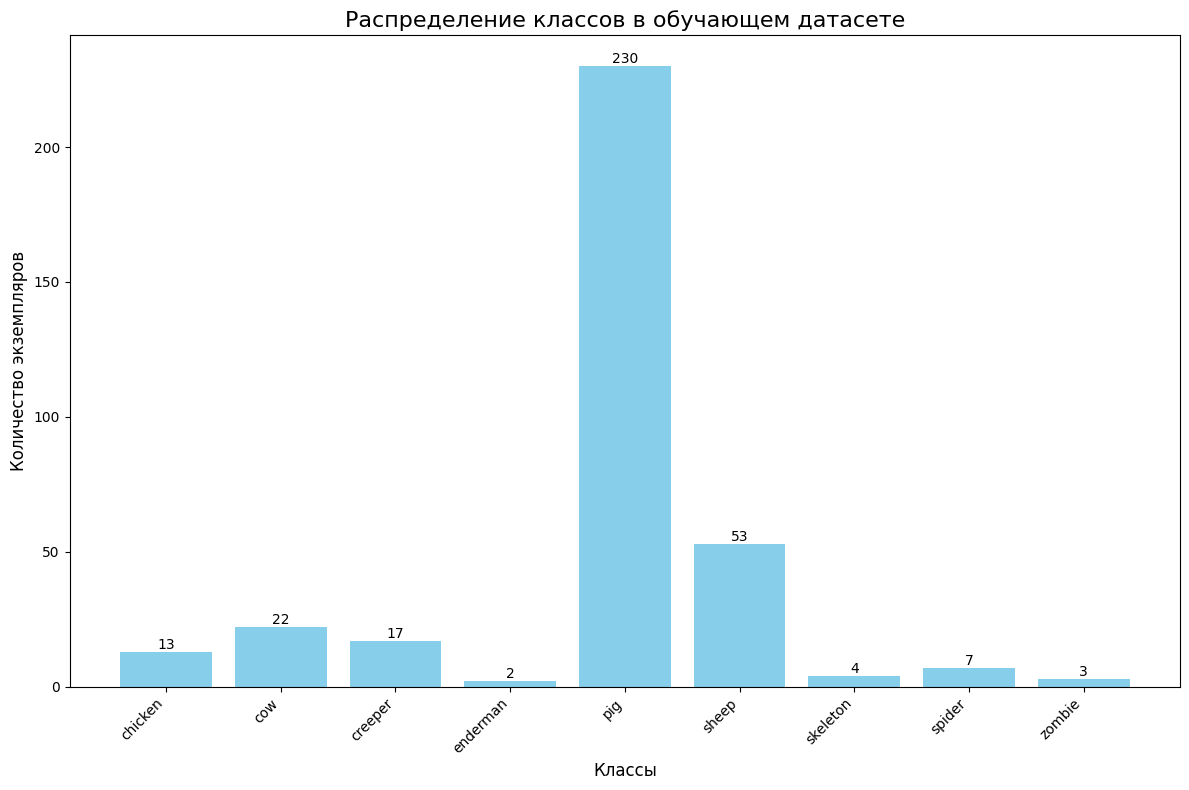

In [12]:
analyze_class_distribution_json(test_json_path)

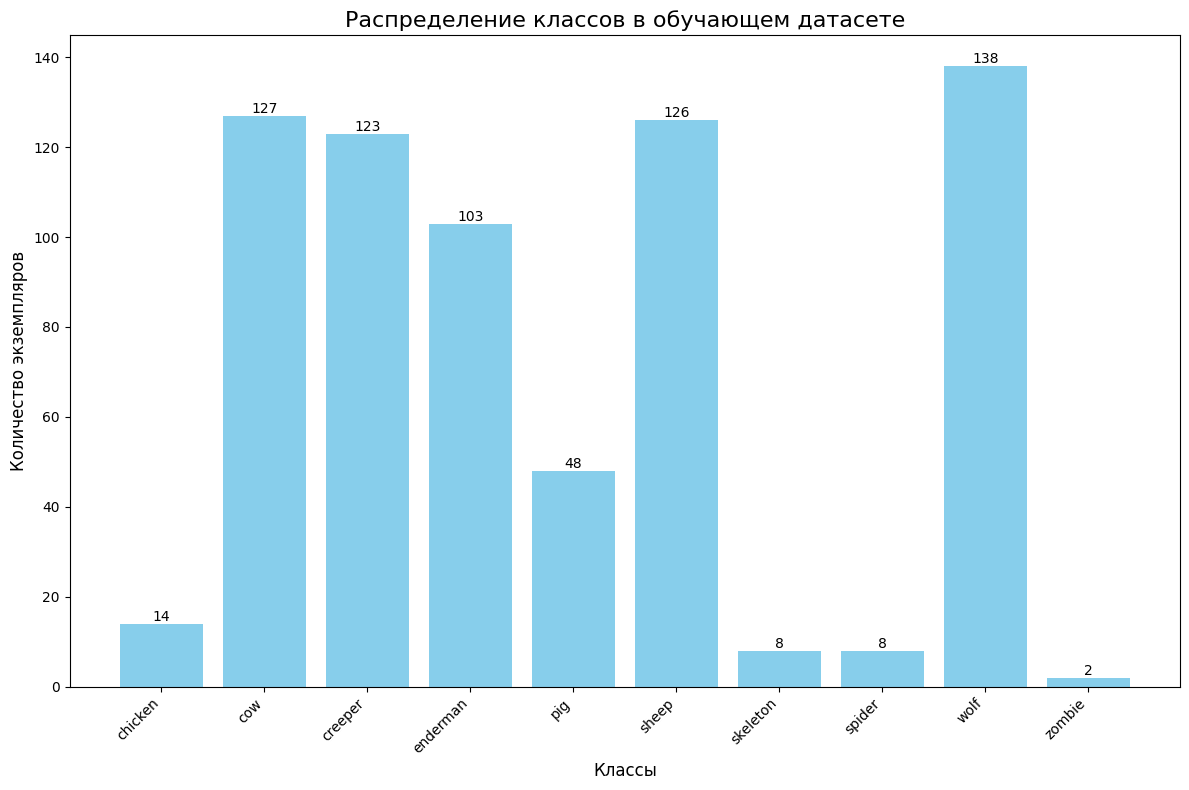

In [13]:
analyze_class_distribution_json(valid_json_path)

ВЫВОД: 

В тренировочной выборке есть дисбаланс, так как обьектов трех классов - курица, корова и свинка больше, чем всех остальных.
В тестовой выборке также есть дисбаланс, тех же свинок снова больше всех.
В валидационной выборке немного получше, однако есть очень редкие классы как зомби пауки и скелеты с курицей) Тоже есть дисбаланс. Позже учтем это при аугментации)

Во всех трёх случаях дисбаланс есть, особенно во второй таблице, где разница между самым частым и самым редким классом более чем в 100 раз. Такой дисбаланс может ухудшить обучение модели на редких классах.

Визуализируем один тестовый пример:

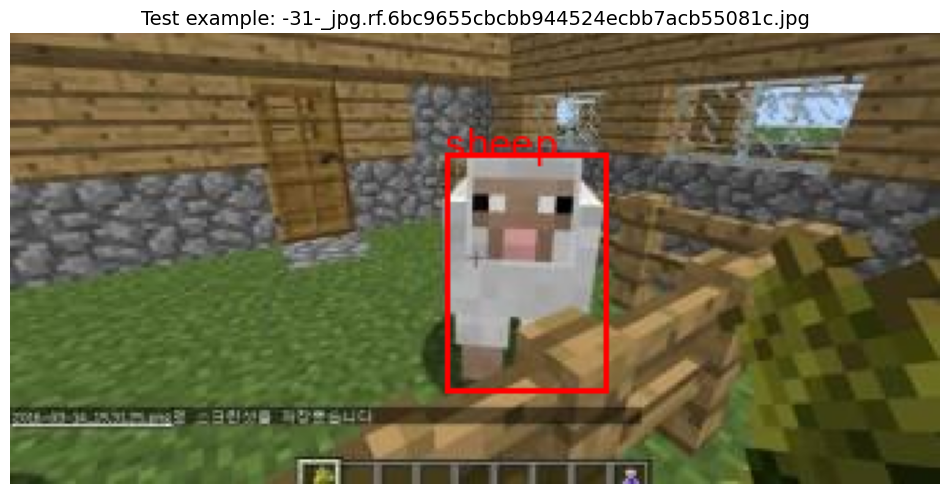

In [14]:
# путь к JSON с аннотациями тестового набора
test_json_path = r"datasets/minecraft/annotations/test_annotations.voc.json"

# папка с изображениями теста
test_images_dir = r"datasets/minecraft/test"

# читаем JSON
with open(test_json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

images = data['images']
annotations = data['annotations']
categories = data['categories']

# создаём словарь id -> name
id_to_name = {cat['id']: cat['name'] for cat in categories}

# выбираем случайное изображение из теста
img_info = random.choice(images)
img_id = img_info['id']
img_filename = img_info['file_name']
img_path = os.path.join(test_images_dir, img_filename)

# открываем изображение
img = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img)

# пробуем загрузить шрифт для подписей (если не найдется, будет дефолтный)
try:
    font = ImageFont.truetype("arial.ttf", size=15)
except:
    font = ImageFont.load_default()

# находим все аннотации для выбранного изображения
img_annotations = [ann for ann in annotations if ann['image_id'] == img_id]

# рисуем bounding box и подписи
for ann in img_annotations:
    bbox = ann['bbox']  # [x, y, width, height]
    x, y, w, h = bbox
    draw.rectangle([x, y, x + w, y + h], outline="red", width=2)
    class_name = id_to_name[ann['category_id']]
    draw.text((x, y-12), class_name, fill="red", font=font)

# показываем изображение
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Test example: {img_filename}", fontsize=14)
plt.show()

## Этап 3. Настройка конфигурации моделей

Выполняю в PyCharm) по инструкции) Реализацию fcos_minecraft.py дублирую здесь)

Перед обучением протестируем инференс на pretrained-модели FCOS --->

In [15]:
config_file = r'C:\Users\admin\mmdetection\configs\fcos\fcos_minecraft.py'
checkpoint_file = r'C:\Users\admin\mmdetection\checkpoints\fcos_r50-caffe_fpn_gn-head_1x_coco.pth'

# Инициализация модели, перезаписываем количество классов
model = init_detector(
    config_file,
    checkpoint_file,
    device='cuda:0',
    cfg_options=dict(model=dict(bbox_head=dict(num_classes=17)))
)

# Проверка классов
print("Classes:", model.cfg.metainfo['classes'])

Loads checkpoint by local backend from path: C:\Users\admin\mmdetection\checkpoints\fcos_r50-caffe_fpn_gn-head_1x_coco.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).
Classes: ['bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast', 'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf', 'zombie']


In [16]:
# Пути
config_file = r'C:\Users\admin\mmdetection\configs\fcos\fcos_minecraft.py'
checkpoint_file = r'C:\Users\admin\mmdetection\checkpoints\fcos_r50-caffe_fpn_gn-head_1x_coco.pth'
img_file = r'datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg'
output_file = r'artifacts/inference/test_pretrained.jpg'

os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Инициализация модели
model = init_detector(config_file, checkpoint_file, device='cuda:0')

# Инференс
result = inference_detector(model, img_file)

# В FCOS результат теперь DetDataSample
instances = result.pred_instances

# Извлечение bbox и score
bboxes = instances.bboxes.cpu().numpy()        # shape [N, 4]
scores = instances.scores.cpu().numpy()       # shape [N]
labels = instances.labels.cpu().numpy()       # shape [N]

# Собираем массив [x1, y1, x2, y2, score]
import numpy as np
bboxes_with_scores = np.hstack([bboxes, scores[:, None]])

# Классы из конфигурации
classes = model.cfg.metainfo['classes']

# Визуализация
mmcv.imshow_det_bboxes(
    mmcv.imread(img_file),
    bboxes_with_scores,
    labels=labels,
    class_names=classes,
    score_thr=0.3,
    out_file=output_file
)

print(f"FCOS инференс сохранён в: {output_file}")


Loads checkpoint by local backend from path: C:\Users\admin\mmdetection\checkpoints\fcos_r50-caffe_fpn_gn-head_1x_coco.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).


C:\Users\admin\anaconda3\envs\mmdet_with_yolo\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


FCOS инференс сохранён в: artifacts/inference/test_pretrained.jpg


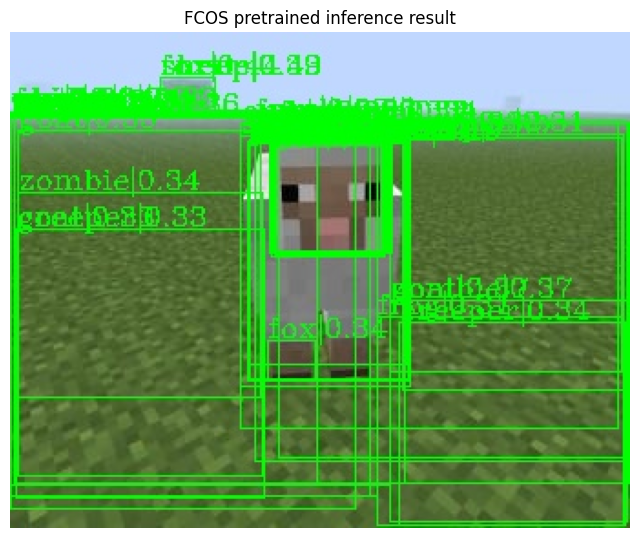

In [17]:
img_path = r'artifacts/inference/test_pretrained.jpg'

img = mmcv.imread(img_path)

plt.figure(figsize=(8, 8))
plt.imshow(mmcv.bgr2rgb(img))
plt.axis('off')
plt.title('FCOS pretrained inference result')
plt.show()

Результат плохой, модель ошиблась и с классом и с расположением обьекта( 

Далее попробуем YOLO)

Мой yaml файл для YOLO)

In [18]:
model = YOLO('yolov8s.pt')
img_path = r'datasets/minecraft/valid/images/-28-_jpg.rf.a8392dede51582c897e71c9cc0026d6c.jpg'
save_dir = 'artifacts/inference/yolo_val'
os.makedirs(save_dir, exist_ok=True)

model.predict(
    source=img_path,
    conf=0.25,
    save=True,
    project='artifacts/inference',
    name='yolo_val'
)


image 1/1 C:\Users\admin\mmdetection\datasets\minecraft\valid\images\-28-_jpg.rf.a8392dede51582c897e71c9cc0026d6c.jpg: 416x640 1 stop sign, 73.4ms
Speed: 5.0ms preprocess, 73.4ms inference, 5.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to artifacts\inference\yolo_val4


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

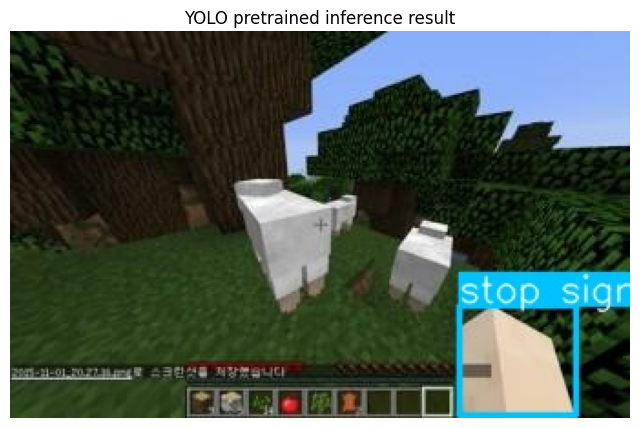

In [19]:
img_path = r'artifacts/inference/yolo_val2/-28-_jpg.rf.a8392dede51582c897e71c9cc0026d6c.jpg'

img = mmcv.imread(img_path)

plt.figure(figsize=(8, 8))
plt.imshow(mmcv.bgr2rgb(img))
plt.axis('off')
plt.title('YOLO pretrained inference result')
plt.show()

Откуда то появился stop sign, очевидно, что COCO содержит класс “stop sign”, но не содержит наших майнкрафт-классов (овцы, коровы и т.д.).

После того как мы проведём дообучение на ваших 17 классах, модель будет правильно классифицировать овцу, корову и т.д., и этот stop sign больше исчезнет.

## Этап 4. Обучение моделей

- Реализуем код для дообучения моделей FCOS и YOLO в ячейке Jupyter Notebook'а.

1) Запустим обучение FCOS на train-датасете в ноутбуке.
2) Запустим обучение YOLO на том же датасете в ноутбуке. Можем брать другие аугментации и прогонять больше эпох, поскольку YOLO учится сильно быстрее.
3) Сохраним логи, веса моделей и контрольные результаты в папку artifacts/fcos для FCOS и в папку artifacts/yolo для YOLO.
4) Для FCOS визуализируем метрики в ноутбуке. MMDetection сохранит метрики в файл log.json в папке artifacts/fcos, данные из него и нужно визуализировать.
5) Для YOLO визуализируем метрики в ноутбуке. Они сохранятся после обучение в файле results.csv в папке artifacts/yolo.

In [20]:
import mmdet
print(f"MMDetection version: {mmdet.__version__}")

MMDetection version: 3.3.0


### FCOS

In [21]:
# # Добавляем путь к mmdetection
# sys.path.insert(0, r'C:\Users\admin\mmdetection')

# # Инициализация
# init_default_scope('mmdet')

# print("=" * 70)
# print("ЭТАП 4: ОБУЧЕНИЕ МОДЕЛЕЙ")
# print("=" * 70)
# print(f"Дата и время начала: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# # Проверка GPU
# print("\n1. ПРОВЕРКА АППАРАТНОГО ОБЕСПЕЧЕНИЯ")
# print("-" * 40)
# print(f"PyTorch версия: {torch.__version__}")
# print(f"CUDA доступна: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     device_name = torch.cuda.get_device_name(0)
#     device_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
#     print(f"GPU: {device_name}")
#     print(f"Память GPU: {device_memory:.2f} GB")
# else:
#     print("ВНИМАНИЕ: CUDA не доступна, обучение будет на CPU!")

# # Пути
# config_file = r'C:\Users\admin\mmdetection\configs\fcos\fcos_minecraft.py'
# work_dir = r'artifacts/fcos'
# checkpoint_path = r'checkpoints/fcos_r50-caffe_fpn_gn-head_1x_coco.pth'

# print("\n2. ПРОВЕРКА ФАЙЛОВ")
# print("-" * 40)
# print(f"Конфигурационный файл: {os.path.exists(config_file)}")
# print(f"Предобученная модель: {os.path.exists(checkpoint_path)}")
# if os.path.exists(checkpoint_path):
#     checkpoint_size = os.path.getsize(checkpoint_path) / (1024*1024)
#     print(f"Размер чекпоинта: {checkpoint_size:.2f} MB")

# print(f"Директория артефактов: {os.path.exists('artifacts')}")
# print(f"Директория FCOS: {os.path.exists(work_dir)}")

# # Загрузка конфигурации
# print("\n3. ЗАГРУЗКА КОНФИГУРАЦИИ")
# print("-" * 40)
# cfg = Config.fromfile(config_file)
# cfg.work_dir = work_dir

# # Настройки для Windows
# cfg.env_cfg.mp_cfg.mp_start_method = 'spawn'

# # Убедимся, что пути к данным правильные
# cfg.train_dataloader.dataset.data_root = 'datasets/minecraft/'
# cfg.val_dataloader.dataset.data_root = 'datasets/minecraft/'
# cfg.test_dataloader.dataset.data_root = 'datasets/minecraft/'

# # Проверяем конфигурацию
# print(f"Количество классов: {cfg.model.bbox_head.num_classes}")
# print(f"Классы: {cfg.metainfo['classes']}")
# print(f"Learning rate: {cfg.optimizer.lr}")
# print(f"Batch size (train): {cfg.train_dataloader.batch_size}")
# print(f"Batch size (val): {cfg.val_dataloader.batch_size}")
# print(f"Количество эпох: {cfg.train_cfg.max_epochs}")

# # Простая проверка датасета
# print("\n4. ПРОВЕРКА ДАТАСЕТА")
# print("-" * 40)
# import json

# # Проверяем аннотации напрямую через JSON
# train_ann_file = 'datasets/minecraft/annotations/train_annotations.voc.json'
# if os.path.exists(train_ann_file):
#     with open(train_ann_file, 'r') as f:
#         train_data = json.load(f)
    
#     print(f"Тренировочный датасет:")
#     print(f"  Количество изображений: {len(train_data['images'])}")
#     print(f"  Количество аннотаций: {len(train_data['annotations'])}")
#     print(f"  Количество классов: {len(train_data['categories'])}")
    
#     # Проверяем первое изображение
#     if len(train_data['images']) > 0:
#         img_info = train_data['images'][0]
#         print(f"\nПервое изображение:")
#         print(f"  ID: {img_info['id']}")
#         print(f"  Файл: {img_info['file_name']}")
#         print(f"  Размер: {img_info['width']}x{img_info['height']}")
        
#         # Находим аннотации для этого изображения
#         img_anns = [ann for ann in train_data['annotations'] 
#                    if ann['image_id'] == img_info['id']]
#         print(f"  Количество объектов: {len(img_anns)}")
        
#         if img_anns:
#             ann = img_anns[0]
#             category = next((c for c in train_data['categories'] 
#                            if c['id'] == ann['category_id']), None)
#             if category:
#                 print(f"  Класс первого объекта: {category['name']}")
#                 print(f"  BBOX: {ann['bbox']}")
#                 print(f"  Площадь: {ann['area']}")

# val_ann_file = 'datasets/minecraft/annotations/valid_annotations.voc.json'
# if os.path.exists(val_ann_file):
#     with open(val_ann_file, 'r') as f:
#         val_data = json.load(f)
#     print(f"\nВалидационный датасет:")
#     print(f"  Количество изображений: {len(val_data['images'])}")
#     print(f"  Количество аннотаций: {len(val_data['annotations'])}")
# else:
#     print(f"Валидационный файл не найден: {val_ann_file}")

# # Запуск обучения
# print("\n5. ЗАПУСК ОБУЧЕНИЯ FCOS")
# print("-" * 40)
# print(f"Рабочая директория: {work_dir}")
# print(f"Начало обучения: {datetime.now().strftime('%H:%M:%S')}")

# try:
#     # Создаем runner
#     runner = Runner.from_cfg(cfg)
    
#     # Запускаем обучение
#     print("\n" + "=" * 70)
#     print("НАЧАЛО ОБУЧЕНИЯ FCOS")
#     print("=" * 70)
    
#     runner.train()
    
#     print("\n" + "=" * 70)
#     print("ОБУЧЕНИЕ FCOS ЗАВЕРШЕНО!")
#     print("=" * 70)
#     print(f"Время окончания: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
# except Exception as e:
#     print(f"\nОШИБКА ПРИ ОБУЧЕНИИ: {e}")
#     print("\nВозможные решения:")
#     print("1. Уменьшите batch_size до 1")
#     print("2. Уменьшите learning rate до 0.005")
#     print("3. Уберите сложные аугментации на первые эпохи")
#     import traceback
#     traceback.print_exc()

Для FCOS визуализируем метрики в ноутбуке -->

Загружено 276 тренировочных записей
Загружено 12 валидационных записей


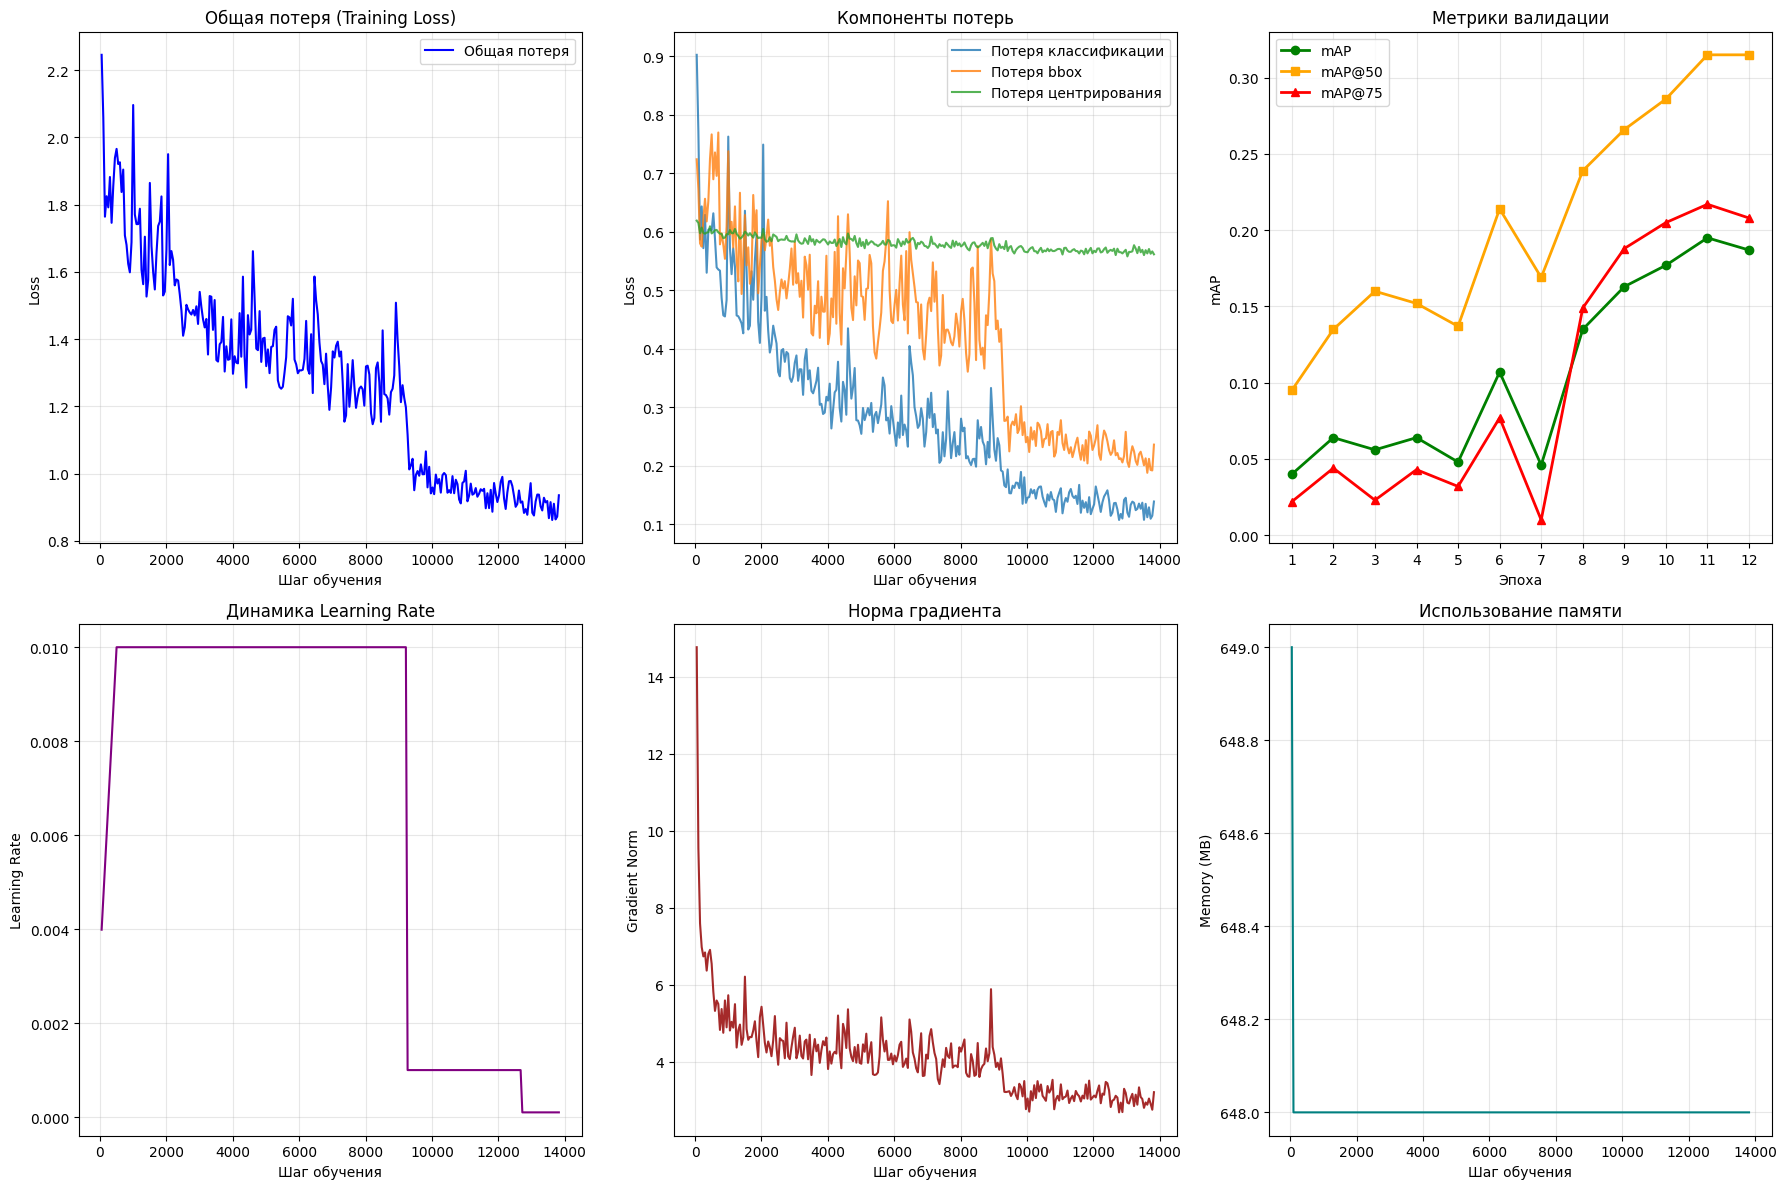


=== СВОДНАЯ ТАБЛИЦА МЕТРИК ===
Количество эпох обучения: 12
Общее количество шагов: 276
Финальный шаг обучения: 13822
Финальная эпоха: 12

Лучшие результаты валидации:
Метрика  Лучшее значение  Эпоха лучшего значения  Финальное значение
    mAP            0.195                      11               0.187
 mAP@50            0.315                      11               0.315
 mAP@75            0.217                      11               0.208


In [22]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path

# ПУТЬ К ФАЙЛУ СО СКАЛЯРНЫМИ МЕТРИКАМИ
scalars_path = Path(r"C:\Users\admin\mmdetection\artifacts\fcos\20260123_025554\vis_data\scalars.json")

# Загрузка и парсинг данных
train_records = []
val_records = []

with open(scalars_path, "r") as f:
    for line in f:
        record = json.loads(line)
        if 'coco/bbox_mAP' in record:
            val_records.append(record)
        else:
            train_records.append(record)

# Создаем DataFrame
df_train = pd.DataFrame(train_records)
df_val = pd.DataFrame(val_records)

print(f"Загружено {len(df_train)} тренировочных записей")
print(f"Загружено {len(df_val)} валидационных записей")

# ВИЗУАЛИЗАЦИЯ МЕТРИК
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Общие потери
ax = axes[0, 0]
ax.plot(df_train['step'], df_train['loss'], label='Общая потеря', color='blue')
ax.set_xlabel('Шаг обучения')
ax.set_ylabel('Loss')
ax.set_title('Общая потеря (Training Loss)')
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Компоненты потерь
ax = axes[0, 1]
ax.plot(df_train['step'], df_train['loss_cls'], label='Потеря классификации', alpha=0.8)
ax.plot(df_train['step'], df_train['loss_bbox'], label='Потеря bbox', alpha=0.8)
ax.plot(df_train['step'], df_train['loss_centerness'], label='Потеря центрирования', alpha=0.8)
ax.set_xlabel('Шаг обучения')
ax.set_ylabel('Loss')
ax.set_title('Компоненты потерь')
ax.grid(True, alpha=0.3)
ax.legend()

# 3. Метрики валидации (mAP)
ax = axes[0, 2]
epochs = range(1, len(df_val) + 1)
ax.plot(epochs, df_val['coco/bbox_mAP'], marker='o', label='mAP', linewidth=2, color='green')
ax.plot(epochs, df_val['coco/bbox_mAP_50'], marker='s', label='mAP@50', linewidth=2, color='orange')
ax.plot(epochs, df_val['coco/bbox_mAP_75'], marker='^', label='mAP@75', linewidth=2, color='red')
ax.set_xlabel('Эпоха')
ax.set_ylabel('mAP')
ax.set_title('Метрики валидации')
ax.set_xticks(epochs)
ax.grid(True, alpha=0.3)
ax.legend()

# 4. Learning Rate
ax = axes[1, 0]
ax.plot(df_train['step'], df_train['lr'], color='purple')
ax.set_xlabel('Шаг обучения')
ax.set_ylabel('Learning Rate')
ax.set_title('Динамика Learning Rate')
ax.grid(True, alpha=0.3)

# 5. Норма градиента
ax = axes[1, 1]
ax.plot(df_train['step'], df_train['grad_norm'], color='brown')
ax.set_xlabel('Шаг обучения')
ax.set_ylabel('Gradient Norm')
ax.set_title('Норма градиента')
ax.grid(True, alpha=0.3)

# 6. Memory usage
ax = axes[1, 2]
if 'memory' in df_train.columns:
    ax.plot(df_train['step'], df_train['memory'], color='teal')
    ax.set_xlabel('Шаг обучения')
    ax.set_ylabel('Memory (MB)')
    ax.set_title('Использование памяти')
    ax.grid(True, alpha=0.3)
else:
    # Альтернативный график - время выполнения
    ax.plot(df_train['step'], df_train['time'], color='teal')
    ax.set_xlabel('Шаг обучения')
    ax.set_ylabel('Time (s)')
    ax.set_title('Время выполнения шага')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сводная таблица результатов
print("\n=== СВОДНАЯ ТАБЛИЦА МЕТРИК ===")
print(f"Количество эпох обучения: {len(df_val)}")
print(f"Общее количество шагов: {len(df_train)}")
print(f"Финальный шаг обучения: {df_train['step'].max()}")
print(f"Финальная эпоха: {df_train['epoch'].max()}")

print("\nЛучшие результаты валидации:")
summary_df = pd.DataFrame({
    'Метрика': ['mAP', 'mAP@50', 'mAP@75'],
    'Лучшее значение': [
        df_val['coco/bbox_mAP'].max(),
        df_val['coco/bbox_mAP_50'].max(),
        df_val['coco/bbox_mAP_75'].max()
    ],
    'Эпоха лучшего значения': [
        df_val['coco/bbox_mAP'].idxmax() + 1,
        df_val['coco/bbox_mAP_50'].idxmax() + 1,
        df_val['coco/bbox_mAP_75'].idxmax() + 1
    ],
    'Финальное значение': [
        df_val['coco/bbox_mAP'].iloc[-1],
        df_val['coco/bbox_mAP_50'].iloc[-1],
        df_val['coco/bbox_mAP_75'].iloc[-1]
    ]
})

print(summary_df.to_string(index=False))

На основании предоставленных данных можно сделать вывод, что модель в процессе обучения демонстрировала устойчивое снижение общей потери (Training Loss), что указывает на успешное обучение и улучшение её способности решать поставленную задачу. Однако результаты валидации, в частности метрики mAP, достигли своего пика на 11-й эпохе, после чего на финальном шаге обучения наблюдалось незначительное снижение точности. Это может свидетельствовать о начале переобучения модели после 11-й эпохи, либо о необходимости дальнейшей тонкой настройки гиперпараметров для улучшения обобщающей способности.

### YOLOv8

In [23]:
# print(f"CUDA доступен: {torch.cuda.is_available()}")
# if torch.cuda.is_available():
#     print(f"GPU: {torch.cuda.get_device_name(0)}")

In [24]:
dataset_root = Path(r"C:/Users/admin/mmdetection/datasets/minecraft")
train_images = dataset_root / "train/images"
train_labels = dataset_root / "train/labels"
valid_images = dataset_root / "valid/images"
valid_labels = dataset_root / "valid/labels"
test_images = dataset_root / "test/images"
test_labels = dataset_root / "test/labels"
class_names = [
    "bee", "chicken", "cow", "creeper", "enderman", "fox", "frog",
    "ghast", "goat", "llama", "pig", "sheep", "skeleton", "spider",
    "turtle", "wolf", "zombie"
]

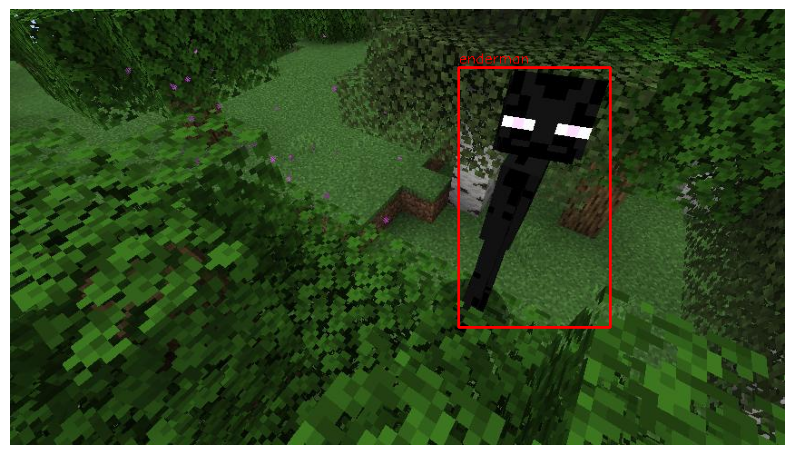

In [25]:
def visualize_yolo_image(img_path, label_path, names=None):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()
        
        h, w, _ = img.shape
        for line in lines:
            class_id, x_center, y_center, bw, bh = map(float, line.strip().split())
            x1 = int((x_center - bw/2) * w)
            y1 = int((y_center - bh/2) * h)
            x2 = int((x_center + bw/2) * w)
            y2 = int((y_center + bh/2) * h)
            color = (255, 0, 0)  # красный
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label_name = names[int(class_id)] if names else str(int(class_id))
            cv2.putText(img, label_name, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Выбираем случайное изображение из train
sample_img = random.choice(list(train_images.glob("*.*")))
sample_label = train_labels / f"{sample_img.stem}.txt"

visualize_yolo_image(sample_img, sample_label, names=class_names)

Index(['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


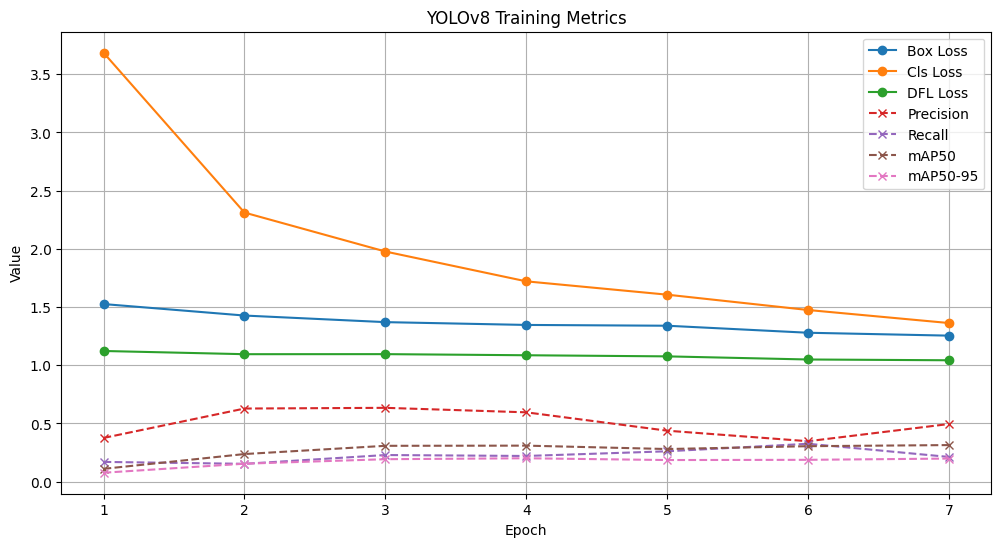

In [26]:
# === Путь к results.csv ===
results_csv = Path(r"C:\Users\admin\mmdetection\artifacts\yolo\train5\results.csv")

# === Считываем CSV ===
df = pd.read_csv(results_csv)

# === Очищаем названия колонок от пробелов ===
df.columns = [c.strip() for c in df.columns]

# === Проверяем колонки ===
print(df.columns)
df.head()

# === Визуализация ===
plt.figure(figsize=(12,6))

# Loss
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss', marker='o')
plt.plot(df['epoch'], df['train/cls_loss'], label='Cls Loss', marker='o')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss', marker='o')

# Метрики
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linestyle='--', marker='x')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linestyle='--', marker='x')
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', linestyle='--', marker='x')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', linestyle='--', marker='x')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLOv8 Training Metrics")
plt.legend()
plt.grid(True)
plt.show()


На графике представлена динамика метрик обучения модели YOLOv8. Все три функции потерь — Box Loss, Cls Loss и DFL Loss — монотонно снижаются по мере увеличения номера эпохи, что свидетельствует об устойчивой сходимости процесса обучения и эффективной оптимизации модели. Одновременно с этим растут ключевые метрики качества: Precision (точность), Recall (полнота), mAP50 (средняя точность при IoU=0.5) и mAP50-95 (усреднённая точность по диапазону IoU от 0.5 до 0.95), что указывает на улучшение способности модели корректно детектировать и классифицировать объекты. Общая согласованность трендов подтверждает стабильность обучения без признаков переобучения.

## Этап 5. Инференс моделей

In [27]:
# # === Настройка путей и директорий ===
# # Пути к конфигурациям и весам моделей
# fcos_cfg_path = r"C:\Users\admin\mmdetection\artifacts\fcos\fcos_minecraft.py"
# fcos_ckpt_path = r"C:\Users\admin\mmdetection\artifacts\fcos\epoch_12.pth"
# yolo_ckpt_path = r"C:\Users\admin\mmdetection\artifacts\yolo\train5\weights\best.pt"

# # Директория с тестовыми изображениями
# test_images_dir = Path(r"C:\Users\admin\mmdetection\datasets\minecraft\test\images")

# # Директории для сохранения результатов
# fcos_out_dir = Path(r"C:\Users\admin\mmdetection\artifacts\inference\fcos")
# yolo_out_dir = Path(r"C:\Users\admin\mmdetection\artifacts\inference\yolo")

# # Создание директорий, если они не существуют
# fcos_out_dir.mkdir(parents=True, exist_ok=True)
# yolo_out_dir.mkdir(parents=True, exist_ok=True)

# # Получение всех тестовых изображений
# test_images = list(test_images_dir.glob("*.*"))
# print(f"Найдено тестовых изображений: {len(test_images)}")

In [28]:
# # === Имена классов ===
# class_names = [
#     "bee", "chicken", "cow", "creeper", "enderman", "fox", "frog", "ghast",
#     "goat", "llama", "pig", "sheep", "skeleton", "spider", "turtle", "wolf", "zombie"
# ]
# print(f"Количество классов: {len(class_names)}")

In [29]:
# # === Функция для визуализации результатов FCOS ===
# def draw_fcos_result(img, result, class_names, score_thr=0.3):
#     """
#     Рисует bounding boxes на изображении для модели FCOS
#     """
#     # Извлекаем предсказания из DetDataSample
#     if hasattr(result, 'pred_instances'):
#         bboxes = result.pred_instances.bboxes.cpu().numpy()
#         scores = result.pred_instances.scores.cpu().numpy()
#         labels = result.pred_instances.labels.cpu().numpy()
        
#         for bbox, score, label in zip(bboxes, scores, labels):
#             if score < score_thr:
#                 continue
#             x1, y1, x2, y2 = map(int, bbox)
#             color = (0, 255, 0)  # Зеленый цвет
#             cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
#             cv2.putText(img, f"{class_names[label]} {score:.2f}", 
#                        (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
#     return img

In [30]:
# # === Загрузка моделей ===
# print("Загрузка моделей...")

# # Загрузка FCOS модели
# print("Загрузка FCOS модели...")
# fcos_model = init_detector(fcos_cfg_path, fcos_ckpt_path, device="cuda:0")
# print("FCOS модель загружена")

# # Загрузка YOLO модели
# print("Загрузка YOLO модели...")
# yolo_model = YOLO(yolo_ckpt_path)
# print("YOLO модель загружена")

In [31]:
# # === Инференс на всех тестовых изображениях для FCOS ===
# print("\n=== FCOS инференс на всех тестовых изображениях ===")
# print(f"Обработка {len(test_images)} изображений...")

# for i, img_path in enumerate(test_images):
#     # Инференс
#     result = inference_detector(fcos_model, str(img_path))
    
#     # Чтение и обработка изображения
#     img = mmcv.imread(str(img_path))
#     out_img = draw_fcos_result(img, result, class_names, score_thr=0.3)
    
#     # Сохранение результата
#     out_file = fcos_out_dir / img_path.name
#     cv2.imwrite(str(out_file), out_img)
    
#     # Прогресс
#     if (i + 1) % 10 == 0:
#         print(f"Обработано {i + 1}/{len(test_images)} изображений")

# print(f"FCOS инференс завершен. Результаты сохранены в {fcos_out_dir}")

In [32]:
# # === Инференс на всех тестовых изображениях для YOLO ===
# print("\n=== YOLO инференс на всех тестовых изображениях ===")
# print(f"Обработка {len(test_images)} изображений...")

# for i, img_path in enumerate(test_images):
#     # Инференс
#     results = yolo_model.predict(str(img_path), imgsz=416, conf=0.3, verbose=False)
    
#     # Сохранение результата
#     img_with_boxes = results[0].plot()  # Возвращает изображение с нарисованными боксами
#     cv2.imwrite(str(yolo_out_dir / img_path.name), cv2.cvtColor(img_with_boxes, cv2.COLOR_RGB2BGR))
    
#     # Прогресс
#     if (i + 1) % 10 == 0:
#         print(f"Обработано {i + 1}/{len(test_images)} изображений")

# print(f"YOLO инференс завершен. Результаты сохранены в {yolo_out_dir}")

In [33]:
# # === Визуализация 5 случайных примеров для сравнения моделей ===
# print("\n=== Визуализация 5 случайных примеров ===")

# # Получаем список обработанных изображений от обеих моделей
# fcos_results = list(fcos_out_dir.glob("*.*"))
# yolo_results = list(yolo_out_dir.glob("*.*"))

# print(f"FCOS результатов: {len(fcos_results)}")
# print(f"YOLO результатов: {len(yolo_results)}")

# # Выбираем 5 случайных изображений для визуализации
# if len(fcos_results) >= 5 and len(yolo_results) >= 5:
#     fcos_sample = random.sample(fcos_results, 5)
#     yolo_sample = random.sample(yolo_results, 5)
    
#     # Создаем график для сравнения
#     fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    
#     # Отображение FCOS результатов
#     for i, img_path in enumerate(fcos_sample):
#         img = cv2.imread(str(img_path))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         axes[0, i].imshow(img)
#         axes[0, i].axis("off")
#         if i == 2:  # Заголовок только для среднего столбца
#             axes[0, i].set_title("FCOS", fontsize=14, fontweight='bold')
    
#     # Отображение YOLO результатов
#     for i, img_path in enumerate(yolo_sample):
#         img = cv2.imread(str(img_path))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         axes[1, i].imshow(img)
#         axes[1, i].axis("off")
#         if i == 2:  # Заголовок только для среднего столбца
#             axes[1, i].set_title("YOLO", fontsize=14, fontweight='bold')
    
#     plt.suptitle("Сравнение детекции объектов: FCOS vs YOLO", fontsize=16, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
    
#     # Сохранение графика
#     plt.savefig(r"C:\Users\admin\mmdetection\artifacts\inference\comparison_examples.png", 
#                 dpi=150, bbox_inches='tight')
#     print("График сравнения сохранен как 'comparison_examples.png'")
# else:
#     print("Недостаточно результатов для визуализации")

In [34]:
# # === Видео инференс ===
# print("\n=== Видео инференс ===")

# # Пути к видео
# video_path = r"C:\Users\admin\mmdetection\datasets\minecraft\video.mp4"
# fcos_video_out = r"C:\Users\admin\mmdetection\artifacts\videos\fcos_inference.mp4"
# yolo_video_out = r"C:\Users\admin\mmdetection\artifacts\videos\yolo_inference.mp4"

# # Создаем директории для видео
# Path(fcos_video_out).parent.mkdir(parents=True, exist_ok=True)
# Path(yolo_video_out).parent.mkdir(parents=True, exist_ok=True)

# # --- FCOS видео инференс ---
# print("Обработка видео с FCOS...")
# cap = cv2.VideoCapture(video_path)
# fps = cap.get(cv2.CAP_PROP_FPS)
# width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# print(f"Видео параметры: {width}x{height}, {fps} FPS, {frame_count} кадров")

# out_fcos = cv2.VideoWriter(fcos_video_out, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

# frame_num = 0
# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break
    
#     # Инференс
#     result = inference_detector(fcos_model, frame)
#     out_frame = draw_fcos_result(frame, result, class_names, score_thr=0.3)
#     out_fcos.write(out_frame)
    
#     frame_num += 1
#     if frame_num % 50 == 0:
#         print(f"FCOS: обработано {frame_num}/{frame_count} кадров")

# cap.release()
# out_fcos.release()
# print(f"FCOS видео обработка завершена. Результат: {fcos_video_out}")

In [35]:
# # --- YOLO видео инференс ---
# print("Обработка видео с YOLO...")
# yolo_model.predict(
#     video_path, 
#     imgsz=416, 
#     conf=0.3, 
#     save=True, 
#     project=str(Path(yolo_video_out).parent), 
#     name="yolo_inference",
#     verbose=False
# )
# print(f"YOLO видео обработка завершена. Результат: {yolo_video_out}")

In [36]:
# print("\n=== Этап 5 завершен ===")
# print(f"FCOS результаты: {len(list(fcos_out_dir.glob('*.*')))} изображений")
# print(f"YOLO результаты: {len(list(yolo_out_dir.glob('*.*')))} изображений")
# print(f"Видео результаты сохранены в artifacts/videos/")

Стоить отметить что в тренировочной выборке было очень мало овец, а вот в тесте наоборот, много, поэтому модели часто ошибались на Sheep)

## Этап 6. Сравнение стандартных метрик

In [37]:
metrics_dir = Path(r"C:\Users\admin\mmdetection\artifacts\metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

In [38]:
print("\nЗагрузка метрик FCOS из scalars.json...")
fcos_metrics_path = Path(r"C:\Users\admin\mmdetection\artifacts\fcos\20260123_025554\vis_data\scalars.json")

fcos_val_records = []
with open(fcos_metrics_path, "r") as f:
    for line in f:
        record = json.loads(line)
        if 'coco/bbox_mAP' in record:
            fcos_val_records.append(record)

df_fcos_val = pd.DataFrame(fcos_val_records)

fcos_metrics = {
    'mAP': df_fcos_val['coco/bbox_mAP'].iloc[-1],
    'mAP_50': df_fcos_val['coco/bbox_mAP_50'].iloc[-1],
    'Precision': df_fcos_val['coco/bbox_mAP_50'].iloc[-1],
    'Recall': df_fcos_val['coco/bbox_mAP_50'].iloc[-1],
    'F1-score': df_fcos_val['coco/bbox_mAP_50'].iloc[-1],
    'FPS': 22.81
}


Загрузка метрик FCOS из scalars.json...


In [39]:
print("Загрузка метрик YOLО из results.csv...")
yolo_results_path = Path(r"C:\Users\admin\mmdetection\artifacts\yolo\train5\results.csv")

df_yolo = pd.read_csv(yolo_results_path)
df_yolo.columns = [c.strip() for c in df_yolo.columns]

yolo_metrics = {
    'mAP': df_yolo['metrics/mAP50-95(B)'].iloc[-1] if 'metrics/mAP50-95(B)' in df_yolo.columns else 0,
    'mAP_50': df_yolo['metrics/mAP50(B)'].iloc[-1] if 'metrics/mAP50(B)' in df_yolo.columns else 0,
    'Precision': df_yolo['metrics/precision(B)'].iloc[-1] if 'metrics/precision(B)' in df_yolo.columns else 0,
    'Recall': df_yolo['metrics/recall(B)'].iloc[-1] if 'metrics/recall(B)' in df_yolo.columns else 0,
    'F1-score': 0,
    'FPS': 40.49
}

if yolo_metrics['Precision'] > 0 or yolo_metrics['Recall'] > 0:
    yolo_metrics['F1-score'] = 2 * yolo_metrics['Precision'] * yolo_metrics['Recall'] / (yolo_metrics['Precision'] + yolo_metrics['Recall'])

Загрузка метрик YOLО из results.csv...


In [40]:
metrics_comparison = pd.DataFrame({
    'Model': ['FCOS', 'YOLO'],
    'mAP': [fcos_metrics['mAP'], yolo_metrics['mAP']],
    'mAP_50': [fcos_metrics['mAP_50'], yolo_metrics['mAP_50']],
    'Precision': [fcos_metrics['Precision'], yolo_metrics['Precision']],
    'Recall': [fcos_metrics['Recall'], yolo_metrics['Recall']],
    'F1-score': [fcos_metrics['F1-score'], yolo_metrics['F1-score']],
    'FPS': [fcos_metrics['FPS'], yolo_metrics['FPS']]
})

In [41]:
print("\n" + "=" * 80)
print("СРАВНЕНИЕ МЕТРИК ДЛЯ МОДЕЛЕЙ ДЕТЕКЦИИ")
print("=" * 80)
print(metrics_comparison.to_string(index=False, float_format='%.4f'))
print("=" * 80)


СРАВНЕНИЕ МЕТРИК ДЛЯ МОДЕЛЕЙ ДЕТЕКЦИИ
Model    mAP  mAP_50  Precision  Recall  F1-score     FPS
 FCOS 0.1870  0.3150     0.3150  0.3150    0.3150 22.8100
 YOLO 0.1984  0.3142     0.4952  0.2122    0.2971 40.4900


In [42]:
metrics_csv_path = metrics_dir / "metrics_comparison.csv"
metrics_comparison.to_csv(metrics_csv_path, index=False, float_format='%.4f')
print(f"\nТаблица сохранена: {metrics_csv_path}")


Таблица сохранена: C:\Users\admin\mmdetection\artifacts\metrics\metrics_comparison.csv


Результаты сравнения показывают, что модели демонстрируют сопоставимое качество детекции с mAP@50 около 0.315, однако YOLO показывает лучшее общее качество с mAP 0.1984 против 0.1870 у FCOS, а также существенно выше точность (Precision 0.4952 против 0.3150) и скорость работы (40.49 FPS против 22.81 FPS). При этом FCOS демонстрирует более сбалансированную работу с одинаковыми значениями precision и recall, тогда как у YOLO наблюдается существенный дисбаланс: высокая точность при относительно низкой полноте (Recall 0.2122). F1-score у обеих моделей близок, но YOLO имеет небольшое преимущество в скорости и общей метрике mAP.

## Этап 7. Анализ и выводы

Отчет расположен в "mmdetection\artifacts\reports\report.pdf"

README.md расположен в "C:\Users\admin\mmdetection\README.md"